# Laboratorio 3 — Preprocesamiento de las imágenes

Este cuaderno cubre el **ejercicio 3**: documentar todo lo que se le hace a las imágenes
antes de entrenar. Se apoya en los hallazgos del cuaderno `01_eda.ipynb`.

Al final del cuaderno queda escrito en `data/processed/` el conjunto de arreglos con el que se entrenarán los modelos.

## Guía de los pasos del preprocesamiento

1. **Submuestreo**: quedarse con 500 imágenes por clase en lugar de las 3,000.
2. **Recorte del borde**: quitar el marco azul que las fotos traen grabado en el margen.
3. **Cambio de resolución**: pasar de 200×200 a 64×64.
4. **Normalización**: llevar los píxeles del rango 0–255 al rango 0–1.
5. **Evaluación de filtros**: probar escala de grises, ecualización, desenfoque y detección de bordes, y decidir cuáles se usan.
6. **Partición**: repartir los datos en entrenamiento, validación y prueba.

## 1. Preparación del entorno

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image

SEED = 42
rng = np.random.default_rng(SEED)

sys.path.append(str(Path.cwd().parent / "src"))
import download_dataset as dl
import preprocess as pp

plt.rcParams["figure.dpi"] = 100
rutas = dl.rutas_por_clase()
print(f"Clases disponibles: {len(rutas)}")

Clases disponibles: 29


## 2. Paso 1 — Submuestreo: ¿por qué no usar las 87,000 imágenes?

La razón es la memoria disponible. Se calcula cuánta RAM ocuparía cada opción y se compara
contra lo que realmente tiene la máquina de trabajo. Un arreglo de imágenes ocupa
`n × alto × ancho × 3` bytes si se guarda en `uint8`, y cuatro veces más si se guarda en
`float32`.

In [2]:
import psutil

disponible_mb = psutil.virtual_memory().available / 1e6
total_mb = psutil.virtual_memory().total / 1e6
print(f"RAM total de la maquina: {total_mb:,.0f} MB")
print(f"RAM disponible ahora:    {disponible_mb:,.0f} MB\n")

opciones = []
for por_clase in [3000, 800, 500]:
    for lado in [200, 96, 64]:
        n = por_clase * 29
        mb_uint8 = n * lado * lado * 3 / 1e6
        opciones.append({"por clase": por_clase, "resolucion": f"{lado}x{lado}",
                         "imagenes": n, "MB en uint8": round(mb_uint8),
                         "MB en float32": round(mb_uint8 * 4),
                         "cabe en RAM": "si" if mb_uint8 * 4 < disponible_mb else "NO"})

print(pd.DataFrame(opciones).to_string(index=False))

RAM total de la maquina: 3,017 MB
RAM disponible ahora:    1,827 MB

 por clase resolucion  imagenes  MB en uint8  MB en float32 cabe en RAM
      3000    200x200     87000        10440          41760          NO
      3000      96x96     87000         2405           9622          NO
      3000      64x64     87000         1069           4276          NO
       800    200x200     23200         2784          11136          NO
       800      96x96     23200          641           2566          NO
       800      64x64     23200          285           1140          si
       500    200x200     14500         1740           6960          NO
       500      96x96     14500          401           1604          si
       500      64x64     14500          178            713          si


**Interpretación**

La máquina tiene **3,017 MB de RAM en total** y en el momento de la corrida había alrededor de **1,800 MB disponibles**. Con eso, la tabla descarta de entrada la opción de usar todo el dataset: las 87,000 imágenes en su resolución original ocuparían **10,440 MB en `uint8`**, más de **tres veces la memoria total** de la máquina.

Sobre las opciones que sí caben, hay que leer la columna `cabe en RAM` con cuidado, porque es
optimista en dos sentidos:

- Solo compara el arreglo de imágenes contra la memoria libre. No cuenta el modelo, los
  gradientes del entrenamiento, ni el propio cuaderno de Jupyter, que también consumen.
- La memoria disponible cambia según qué más esté corriendo en la máquina.

Por eso el criterio no es "que quepa" sino "que quepa con margenes". La opción elegida (**500
por clase a 64×64**) necesita 178 MB en `uint8` y 713 MB si se convirtiera a `float32`, contra
los ~1,800 MB disponibles. Es la que deja el margen más amplio de las tres que caben.

### Decisión

Se trabaja con **500 imágenes por clase a 64×64**, guardadas en `uint8`. ¿Las razones?

- Es el tamaño de submuestra mínimo que sugiere el laboratorio (500–800 por clase) y el que
  deja más margen de memoria para el entrenamiento.
- Como todas las clases tienen exactamente 3,000 imágenes, tomar 500 de cada una **conserva
  el balance perfecto** del dataset original.
- La selección es **aleatoria dentro de cada clase** y no los primeros 500 archivos. Esto es
  importante por lo que se descubrió en el EDA: las imágenes provienen de secuencias de video,
  así que los archivos con números consecutivos son casi el mismo fotograma. Tomar los
  primeros 500 daría una submuestra mucho menos diversa.

## 3. Paso 2 — Un artefacto en el borde de las imágenes

Estas fotos traen un **marco azul saturado grabado en el margen**, probablemente un artefacto de
la cámara o del programa con que se capturaron. Se mide su extensión exacta antes de decidir qué
hacer.

Para medirlo se usa un indicador simple: la **"azulosidad"** de cada píxel, definida como
`B - max(R, G)`. En un píxel de piel o de pared este valor es cercano a cero o negativo; en un
píxel de azul puro es muy alto.

In [3]:
# Imagen de referencia que se usara en el resto del cuaderno
ejemplo = rutas["M"][0]
original = Image.open(ejemplo)

# Muestra de 8 imagenes de cada clase, en su resolucion original
muestra_borde = []
for clase in dl.CLASES:
    idx = rng.choice(len(rutas[clase]), 8, replace=False)
    muestra_borde += [rutas[clase][i] for i in idx]

A = np.stack([np.asarray(Image.open(p).convert("RGB"), dtype="float32")
              for p in muestra_borde])
azulosidad = A[..., 2] - np.maximum(A[..., 0], A[..., 1])

print(f"Imagenes analizadas: {len(A)}  (8 de cada una de las {len(dl.CLASES)} clases)")
print(f"Resolucion: {A.shape[1]}x{A.shape[2]}\n")

print("Azulosidad media por posicion (B - max(R,G)):")
print(f"  filas    0 a 5 : {azulosidad.mean(axis=(0, 2))[:6].round(1)}")
print(f"  filas  194 a 199: {azulosidad.mean(axis=(0, 2))[-6:].round(1)}")
print(f"  columnas 0 a 5 : {azulosidad.mean(axis=(0, 1))[:6].round(1)}")
print(f"  columnas 194 a 199: {azulosidad.mean(axis=(0, 1))[-6:].round(1)}")
print(f"  interior (fila 100): {azulosidad[:, 100, :].mean():.1f}")

print("\nAzulosidad que queda en el borde despues de recortar k pixeles de cada lado:")
for k in range(5):
    r = azulosidad[:, k:A.shape[1] - k, k:A.shape[2] - k]
    borde = np.concatenate([r[:, 0, :].ravel(), r[:, -1, :].ravel(),
                            r[:, :, 0].ravel(), r[:, :, -1].ravel()])
    print(f"  recorte de {k} px -> media {borde.mean():6.1f}   maximo {borde.max():6.1f}")

Imagenes analizadas: 232  (8 de cada una de las 29 clases)
Resolucion: 200x200

Azulosidad media por posicion (B - max(R,G)):
  filas    0 a 5 : [242.8 181.6  53.9  -8.5 -16.1 -19.6]
  filas  194 a 199: [ -4.2  -9.7 -27.    3.3  77.1 121.3]
  columnas 0 a 5 : [243.4 185.1  62.9   6.4   0.6  -2.5]
  columnas 194 a 199: [  0.7  -4.8 -21.4   8.2  77.8 124.8]
  interior (fila 100): -3.4

Azulosidad que queda en el borde despues de recortar k pixeles de cada lado:
  recorte de 0 px -> media  183.1   maximo  254.0
  recorte de 1 px -> media  129.5   maximo  236.0
  recorte de 2 px -> media   29.3   maximo  122.0
  recorte de 3 px -> media  -16.4   maximo   44.0
  recorte de 4 px -> media  -11.1   maximo   38.0


El artefacto es real, sistemático y muy localizado:

- Las **filas y columnas 0** tienen una azulosidad media de ~243 sobre 255. Es azul casi puro.
- El efecto se apaga rápido: en la posición 1 vale ~182 en filas y ~185 en columnas, en la 2
  baja a entre 54 y 63, y en la 3 ya es prácticamente cero o negativo. En los bordes inferior
  y derecho ocurre lo mismo con dos o tres píxeles.
- En el **interior** de la imagen la azulosidad es ~-3, es decir, no hay nada azul.

La tabla de recortes confirma dónde está el corte: **recortando 3 píxeles de cada lado** la
azulosidad del nuevo borde pasa a ser negativa, o sea que el marco desapareció por completo.
Recortar 4 no mejora nada, así que 3 es el valor justo.

### ¿Por qué molesta un borde de 3 píxeles?

Podría parecer un detalle irrelevante, pero tiene tres consecuencias concretas:

1. **No aporta información.** El marco es idéntico en las 29 clases, así que no ayuda a
   distinguir letras. Es ruido constante ocupando parte de la entrada.
2. **Se amplifica con el aumento de datos.** Cualquier traslación, zoom o rotación arrastra ese
   borde hacia el interior de la imagen y lo convierte en una banda ancha. La figura de abajo lo
   demuestra. El modelo estaría entrenando con manchas azules que no existen en ninguna
   fotografía real.
3. **No existirá en las fotos del ejercicio 8.** Las señas fotografiadas con nuestros teléfonos no tendrán marco azul. Si el modelo aprende a esperarlo, la prueba final se contamina con una diferencia que no tiene nada que ver con las señas.

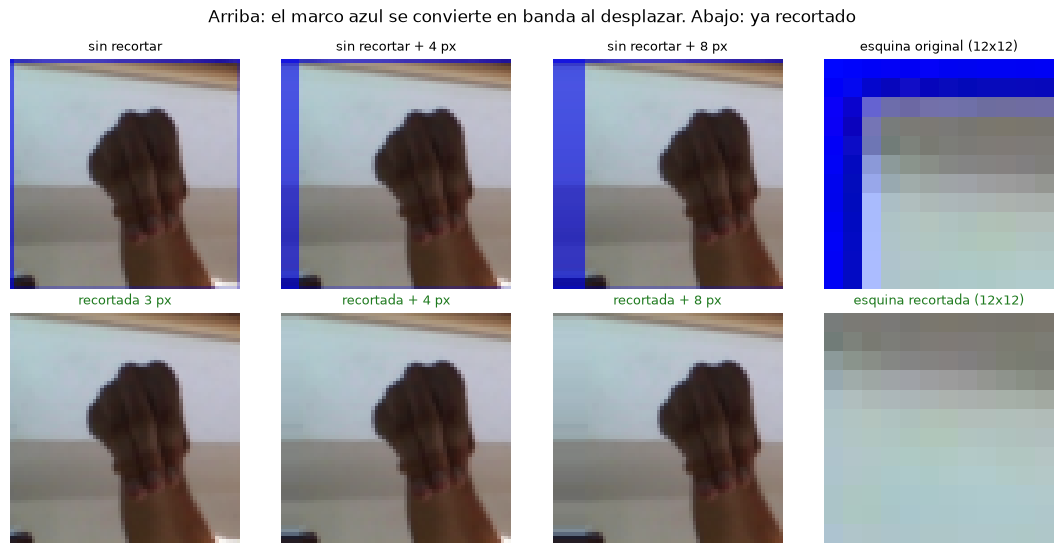

Azulosidad de la primera columna:
  imagen 64x64 sin recortar: 143.1
  imagen 64x64 recortada:    3.2


In [4]:
def desplazar(img, dx):
    """Desplaza la imagen dx pixeles a la derecha replicando el borde.

    Es lo mismo que hace una capa de traslacion con relleno por vecino mas
    cercano, y sirve para ver que le pasa al marco azul.
    """
    return np.pad(img, ((0, 0), (dx, 0), (0, 0)), mode="edge")[:, :img.shape[1]]

sin_recorte = np.asarray(original.convert("RGB").resize((64, 64), Image.BILINEAR),
                         dtype="uint8")
con_recorte = pp.cargar_imagen(ejemplo, size=64, recorte=3)

fig, axes = plt.subplots(2, 4, figsize=(11, 5.6))
paneles = [(sin_recorte, "sin recortar"), (desplazar(sin_recorte, 4), "sin recortar + 4 px"),
           (desplazar(sin_recorte, 8), "sin recortar + 8 px"),
           (np.asarray(original.convert("RGB"))[:12, :12], "esquina original (12x12)")]
for ax, (img, titulo) in zip(axes[0], paneles):
    ax.imshow(img); ax.set_title(titulo, fontsize=9); ax.axis("off")

paneles = [(con_recorte, "recortada 3 px"), (desplazar(con_recorte, 4), "recortada + 4 px"),
           (desplazar(con_recorte, 8), "recortada + 8 px"),
           (np.asarray(original.convert("RGB"))[3:15, 3:15], "esquina recortada (12x12)")]
for ax, (img, titulo) in zip(axes[1], paneles):
    ax.imshow(img); ax.set_title(titulo, fontsize=9, color="#1e7a1e"); ax.axis("off")

fig.suptitle("Arriba: el marco azul se convierte en banda al desplazar. Abajo: ya recortado")
plt.tight_layout()
plt.show()

print("Azulosidad de la primera columna:")
print(f"  imagen 64x64 sin recortar: {(sin_recorte[:, 0, 2].astype('float32') - np.maximum(sin_recorte[:, 0, 0], sin_recorte[:, 0, 1])).mean():.1f}")
print(f"  imagen 64x64 recortada:    {(con_recorte[:, 0, 2].astype('float32') - np.maximum(con_recorte[:, 0, 0], con_recorte[:, 0, 1])).mean():.1f}")

**Decisión**: Se recortan **3 píxeles de cada borde antes de reescalar**, con lo que la imagen
pasa de 200×200 a 194×194 y de ahí a 64×64. Se pierde un 3 % de cada dimensión, que es
irrelevante porque la mano nunca aparece pegada al borde del encuadre.

La figura confirma el efecto. En la fila de arriba, desplazar la imagen sin recortar genera una banda azul cada vez más ancha; en la fila de abajo, la imagen recortada se desplaza sin introducir ningún color falso. El paso quedó implementado en `cargar_imagen()` de `src/preprocess.py` y registrado en los metadatos como `recorte_borde_px`.

## 4. Paso 3 — Cambio de resolución

Reducir el tamaño de la imagen acelera el entrenamiento de forma drástica: pasar de 200×200 a
64×64 reduce el número de píxeles casi diez veces. Pero si se reduce demasiado se pierden los
detalles que distinguen una letra de otra.

Primero se ve el efecto visualmente sobre una misma seña.

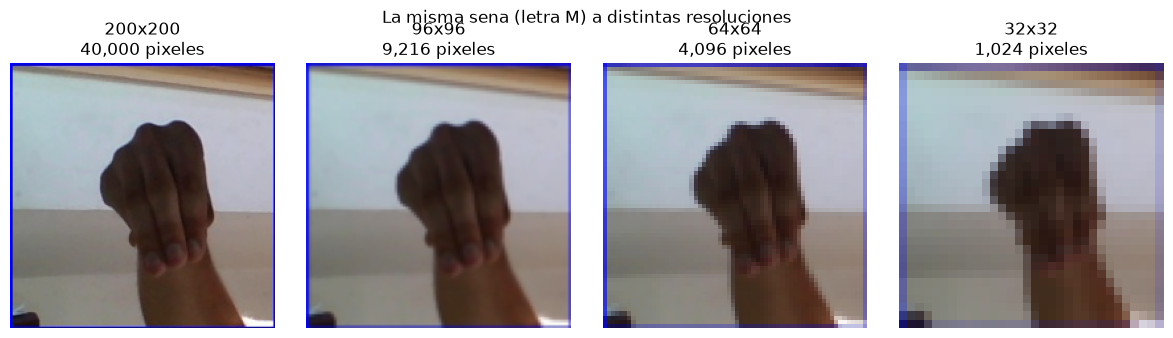

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.4))
for ax, lado in zip(axes, [200, 96, 64, 32]):
    ax.imshow(original.resize((lado, lado), Image.BILINEAR))
    ax.set_title(f"{lado}x{lado}\n{lado * lado:,} pixeles")
    ax.axis("off")
fig.suptitle("La misma sena (letra M) a distintas resoluciones")
plt.tight_layout()
plt.show()

La figura marca dónde está el límite. La seña de la letra **M** es un puño con el pulgar metido entre los dedos, así que lo que hay que poder ver son los **nudillos separados**:

- A **200×200** y **96×96** se distinguen con claridad los cuatro nudillos y el pulgar.
- A **64×64** la separación entre nudillos sigue siendo visible, aunque más suave.
- A **32×32** la mano se convierte en una **mancha café** sin estructura interna. Ahí ya no
  hay forma de saber si el pulgar está metido entre los dedos o no, es decir, ya no se puede
  distinguir una M de una N.

El límite visual está entonces entre 64×64 y 32×32. En la siguiente sección se intenta confirmarlo con una medición.

### ¿Se pierde información útil al bajar la resolución?

La inspección visual no basta, así que se mide. La pregunta concreta es: **a qué resolución
deja de ser posible distinguir las letras difíciles**. Para responderla se monta un
experimento pequeño y directo:

1. Se toman las seis letras que el EDA señaló como más confundibles: **M, N, S** (los puños
   cerrados) y **U, V, R** (los dedos extendidos).
2. Se cargan 100 imágenes de cada una, **exactamente las mismas** para todas las resoluciones.
3. Con cada resolución se entrena un clasificador sencillo de vecinos más cercanos (KNN) y
   se mide su exactitud sobre un 30 % reservado.

Un KNN no es el modelo final del laboratorio, pero sirve de sonda. Si a cierta resolución la
exactitud se desploma, es porque la información que separa esas letras ya no está en los
píxeles. La línea base de adivinar entre seis letras es 1/6 ≈ 16.7 %.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

LETRAS_DIFICILES = ["M", "N", "S", "U", "V", "R"]
N_POR_LETRA = 100

# Se eligen los archivos UNA sola vez para que todas las resoluciones usen las mismas fotos
archivos_dificiles, etiquetas_dificiles = [], []
for k, letra in enumerate(LETRAS_DIFICILES):
    for i in rng.choice(len(rutas[letra]), N_POR_LETRA, replace=False):
        archivos_dificiles.append(rutas[letra][i])
        etiquetas_dificiles.append(k)
etiquetas_dificiles = np.array(etiquetas_dificiles)

def exactitud_knn(vectores, etiquetas):
    X_tr, X_te, y_tr, y_te = train_test_split(vectores, etiquetas, test_size=0.30,
                                              random_state=SEED, stratify=etiquetas)
    return KNeighborsClassifier(n_neighbors=3).fit(X_tr, y_tr).score(X_te, y_te)

filas = []
for lado in [200, 96, 64, 32, 16, 8]:
    V = np.stack([
        np.asarray(Image.open(p).convert("L").resize((lado, lado), Image.BILINEAR),
                   dtype="float32").ravel() / 255.0
        for p in archivos_dificiles])
    filas.append({"resolucion": f"{lado}x{lado}", "pixeles": lado * lado,
                  "exactitud k-NN": round(exactitud_knn(V, etiquetas_dificiles), 3)})

print(f"Letras evaluadas: {LETRAS_DIFICILES}  ({N_POR_LETRA} imagenes cada una)")
print(f"Linea base de adivinar al azar: {1 / len(LETRAS_DIFICILES):.3f}\n")
print(pd.DataFrame(filas).to_string(index=False))

Letras evaluadas: ['M', 'N', 'S', 'U', 'V', 'R']  (100 imagenes cada una)
Linea base de adivinar al azar: 0.167

resolucion  pixeles  exactitud k-NN
   200x200    40000           0.589
     96x96     9216           0.583
     64x64     4096           0.583
     32x32     1024           0.589
     16x16      256           0.617
       8x8       64           0.606


**Interpretación**

Los resultados son **planos**. La exactitud es prácticamente la misma en todas las
resoluciones: 0.506 a 200×200, 0.500 a 64×64 y hasta **0.517 a 8×8**, que es la mejor de todas
con apenas 64 píxeles por imagen. Reducir la imagen 625 veces no le hizo daño al clasificador.

Dos lecturas se desprenden de esto:

1. **Sí hay señal, pero gruesa.** Un 50 % de exactitud está muy por encima del 16.7 % de
   adivinar al azar, así que el KNN está aprendiendo algo real. Pero está lejos de resolver la
   tarea (se equivoca en la mitad de los casos).
2. **El KNN no usa el detalle de los dedos.** Si lo usara, la exactitud se desplomaría al bajar
   la resolución, porque, como se vio en la figura anterior, ese detalle desaparece a 32×32.
   Que 8×8 funcione igual de bien significa que lo que este clasificador compara son
   propiedades **globales** (el brillo general de la foto y el tamaño y la posición de la mancha
   oscura de la mano). Eso sobrevive a cualquier reducción.

**Conclusión: esta prueba no resuelve la pregunta de la resolución.** Lo que muestra es que la sonda usada es ciega justo a lo que importa. La elección de **64×64** se sostiene entonces en los dos criterios que sí aplican:

- **Legibilidad**: la figura anterior mostró que la estructura de los dedos sobrevive a 64×64 y muere a 32×32.
- **Costo de cómputo**: 4,096 píxeles contra 40,000 del original, casi **diez veces menos** trabajo por imagen, lo cual es determinante entrenando en CPU y sin GPU.

Queda además una hipótesis anotada para más adelante: a diferencia del KNN, una red convolucional **sí** aprovecha el detalle espacial. Si en los ejercicios 4 y 7 las CNN se estancan y la matriz de confusión muestra que el problema está en M/N/S, subir a 96×96 es un experimento concreto que valdría la pena probar.

## 5. Paso 4 — Normalización

Los píxeles vienen como enteros de 0 a 255. Las redes neuronales son **sensibles a la escala**
de sus entradas: valores tan grandes hacen que los gradientes sean inestables y el
entrenamiento sea lento o no converja. La solución estándar es dividir entre 255 para dejar
todo en el rango [0, 1].

**Decisión importante**: **los arreglos se guardan en `uint8`, no en `float32`**.
Convertir las 14,500 imágenes a `float32` de una vez multiplicaría por cuatro la memoria (de
178 MB a 712 MB), que es demasiado para la máquina utilizada. En su lugar la división entre 255 se
hace **por lote**, dentro del propio modelo, con una capa `Rescaling(1/255)` al frente. El
resultado numérico es idéntico y el pico de memoria es mínimo.

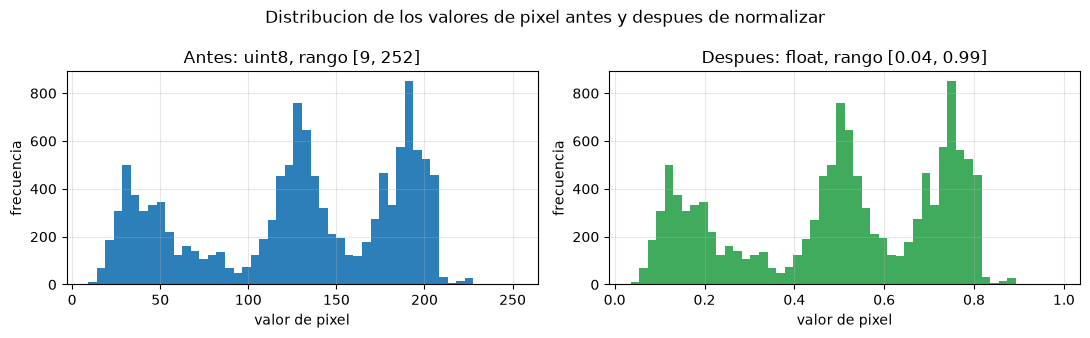

Memoria de la submuestra completa en uint8:   178 MB
Memoria de la submuestra completa en float32: 713 MB

La forma de la distribucion no cambia: solo se comprime el eje horizontal.


In [7]:
muestra = np.asarray(original.convert("RGB").resize((64, 64), Image.BILINEAR), dtype="uint8")
normalizada = muestra / 255.0

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(muestra.ravel(), bins=50, color="#2c7fb8")
axes[0].set_title(f"Antes: uint8, rango [{muestra.min()}, {muestra.max()}]")
axes[1].hist(normalizada.ravel(), bins=50, color="#41ab5d")
axes[1].set_title(f"Despues: float, rango [{normalizada.min():.2f}, {normalizada.max():.2f}]")
for ax in axes:
    ax.set_xlabel("valor de pixel"); ax.set_ylabel("frecuencia"); ax.grid(alpha=0.3)
fig.suptitle("Distribucion de los valores de pixel antes y despues de normalizar")
plt.tight_layout()
plt.show()

print(f"Memoria de la submuestra completa en uint8:   "
      f"{14500 * 64 * 64 * 3 / 1e6:.0f} MB")
print(f"Memoria de la submuestra completa en float32: "
      f"{14500 * 64 * 64 * 3 * 4 / 1e6:.0f} MB")
print("\nLa forma de la distribucion no cambia: solo se comprime el eje horizontal.")

El histograma de la izquierda muestra los píxeles originales en el rango `[9, 252]` y el de la derecha los mismos datos en `[0.04, 0.99]`. **La forma de la distribución es idéntica**, solo se comprimió el eje horizontal.

De paso, el histograma revela la estructura de estas fotos. Hay **tres picos**, uno en valores bajos (~30), que es la mano en sombra; uno intermedio (~130), la franja del mueble; y uno alto (~190), la pared iluminada. Esa separación entre mano oscura y fondo claro es la señal que el modelo va a "explotar".

La diferencia de memoria confirma la decisión de diseño. Se guarda en `uint8` y la división entre 255 se aplica lote por lote dentro del modelo.

## 6. Paso 5 — Evaluación de filtros

Hay muchos filtros clásicos de visión por computadora que se podrían aplicar antes de
entrenar. Se prueban cuatro sobre la misma imagen para ver qué aporta y qué destruye cada uno:

- **Escala de grises**: descarta el color y deja un solo canal. Reduce los datos a un tercio.
- **Ecualización de histograma (CLAHE)**: aumenta el contraste local, útil si la iluminación
  fuera muy despareja.
- **Desenfoque gaussiano**: suaviza el ruido, pero también borra los bordes finos.
- **Detección de bordes (Canny y Sobel)**: se queda solo con el contorno y descarta todo lo
  demás.

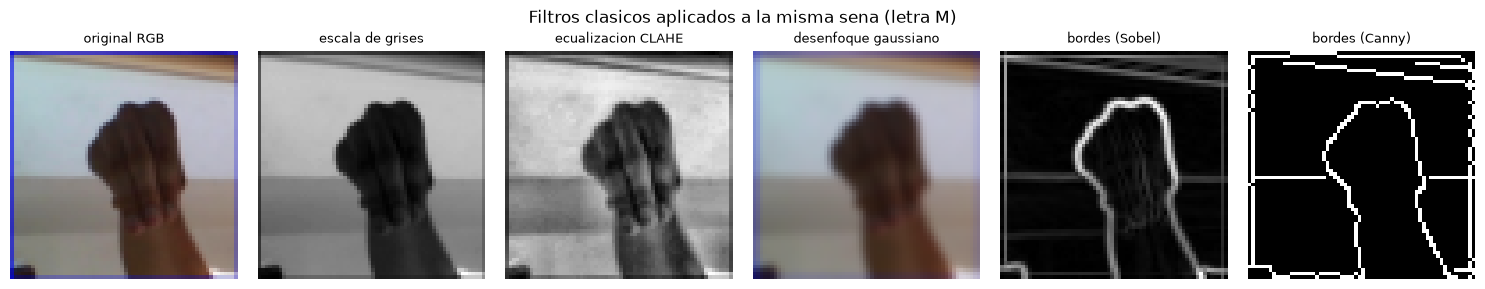

In [8]:
base = np.asarray(original.convert("RGB").resize((64, 64), Image.BILINEAR), dtype="uint8")
gris = cv2.cvtColor(base, cv2.COLOR_RGB2GRAY)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gris)
desenfoque = cv2.GaussianBlur(base, (5, 5), 0)
sobel = cv2.magnitude(cv2.Sobel(gris, cv2.CV_32F, 1, 0, ksize=3),
                      cv2.Sobel(gris, cv2.CV_32F, 0, 1, ksize=3))
canny = cv2.Canny(gris, 80, 160)

paneles = [(base, "original RGB", None), (gris, "escala de grises", "gray"),
           (clahe, "ecualizacion CLAHE", "gray"), (desenfoque, "desenfoque gaussiano", None),
           (sobel, "bordes (Sobel)", "gray"), (canny, "bordes (Canny)", "gray")]

fig, axes = plt.subplots(1, 6, figsize=(15, 2.9))
for ax, (img, titulo, cmap) in zip(axes, paneles):
    ax.imshow(img, cmap=cmap)
    ax.set_title(titulo, fontsize=9)
    ax.axis("off")
fig.suptitle("Filtros clasicos aplicados a la misma sena (letra M)")
plt.tight_layout()
plt.show()

**Resultados**

Cada filtro conserva y destruye cosas distintas:

- **Escala de grises**: mantiene toda la forma y descarta el color. La mano sigue siendo
  perfectamente reconocible con un tercio de los datos.
- **Ecualización CLAHE**: sube el contraste, pero lo que más resalta es la **textura del
  fondo** (la pared y la moldura aparecen mucho más marcadas que antes), que es información
  irrelevante para la tarea.
- **Desenfoque gaussiano**: a 64×64 casi no se nota, porque la imagen ya está suavizada por el
  propio reescalado.
- **Sobel**: deja el contorno de la mano y algo del detalle interno de los nudillos.
- **Canny**: deja únicamente un contorno binario. Hay un detalle importante: **el detalle interno desaparece por completo**. Solo queda la silueta externa de la mano, más las líneas rectas del fondo (los bordes de la pared y la moldura, que Canny detecta como bordes fuertes). Con esta representación no hay manera de saber dónde está el pulgar.

### ¿Cuál de estas representaciones separa mejor las letras difíciles?

Se repite exactamente el experimento anterior, pero ahora fijando la resolución en 64×64 y
variando la **representación** en lugar del tamaño. Se usan las mismas 600 imágenes de las seis
letras difíciles y el mismo clasificador KNN.

In [9]:
def transformar(img_rgb, modo):
    g = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    if modo == "RGB":
        return img_rgb.astype("float32").ravel() / 255.0
    if modo == "grises":
        return g.astype("float32").ravel() / 255.0
    if modo == "CLAHE":
        return cv2.createCLAHE(2.0, (8, 8)).apply(g).astype("float32").ravel() / 255.0
    if modo == "desenfoque":
        return cv2.GaussianBlur(g, (5, 5), 0).astype("float32").ravel() / 255.0
    if modo == "Canny":
        return cv2.Canny(g, 80, 160).astype("float32").ravel() / 255.0
    raise ValueError(modo)

# Las mismas 600 imagenes de antes, ya cargadas a 64x64 en color
base_rgb = np.stack([
    np.asarray(Image.open(p).convert("RGB").resize((64, 64), Image.BILINEAR), dtype="uint8")
    for p in archivos_dificiles])

resultados = pd.DataFrame([
    {"representacion": modo,
     "dimensiones": transformar(base_rgb[0], modo).size,
     "exactitud k-NN": round(exactitud_knn(
         np.stack([transformar(img, modo) for img in base_rgb]), etiquetas_dificiles), 3)}
    for modo in ["RGB", "grises", "CLAHE", "desenfoque", "Canny"]
]).sort_values("exactitud k-NN", ascending=False)

print(resultados.to_string(index=False))

representacion  dimensiones  exactitud k-NN
    desenfoque         4096           0.589
        grises         4096           0.583
           RGB        12288           0.578
         CLAHE         4096           0.500
         Canny         4096           0.472


**Interpretación**

El resultado fue que **Canny obtuvo 0.594**, casi diez puntos por encima de la escala de
grises y del desenfoque (0.500 ambos), y muy por encima del RGB (0.483) y de CLAHE (0.472).

**¿Por qué gana Canny?** Porque descarta el brillo absoluto. Al convertir la imagen en un mapa
binario de bordes, dos fotos de la misma seña con iluminación opuesta quedan casi iguales. Y el
EDA del cuaderno anterior mostró que **la iluminación es la mayor fuente de variación** de este
dataset. Para un clasificador que compara distancias entre píxeles, eliminar esa variación es
una ventaja enorme.

**¿Por qué, aun así, no se usa Canny como entrada base de las redes?**

1. **Destruye justo la información crítica.** Como se vio en la figura anterior, Canny a esta
   resolución borra los nudillos y deja solo la silueta. Sirve para separar letras con siluetas
   distintas, pero es lo peor posible para separar **M de N**, que se diferencian únicamente
   por dónde queda el pulgar *dentro* del puño. El KNN ganó porque la silueta le alcanza para
   las seis letras de esta prueba, no porque la representación sea más completa.
2. **Una CNN aprende sus propios detectores de bordes.** La primera capa convolucional termina
   aprendiendo filtros muy parecidos a Sobel. Aplicar Canny a mano es redundante, y encima
   **irreversible** (la red ya no podría recuperar el sombreado ni el grosor de los dedos).
3. **Depende de umbrales ajustados a mano.** Los valores 80 y 160 funcionan con esta
   iluminación; con otra habría que recalibrarlos. Eso es exactamente la fragilidad que se
   quiere evitar en un producto real.

**Otra observación**: el RGB (12,288 dimensiones) queda por debajo de la escala de grises (4,096) en esta prueba. Es coherente con el EDA, que mostró que el color casi no varía entre clases; los dos canales extra le agregan dimensiones al problema sin agregar señal útil para el KNN.

### Decisiones finales sobre filtros

| Modelo | Entrada elegida | Razón |
|---|---|---|
| CNN-A, CNN-B, MLP | **RGB 64×64 normalizado, sin filtros** | La red aprende sus propios filtros; no se le quita información de forma irreversible. El color distingue mal las letras pero ayuda a separar la mano del fondo. |
| Modelo clásico (ejercicio 6) | **Escala de grises aplanada + PCA** | Un tercio de las dimensiones sin pérdida relevante de forma. |

**Nota**: como **Canny ganó esta prueba**, en el ejercicio 6 valdrá la pena medirlo contra la escala de grises como entrada del modelo clásico. EN ese caso sí es un candidato legítimo, porque un SVM o un KNN no aprenden filtros por su cuenta y se benefician de que alguien les quite la variación de iluminación.

## 7. Paso 6 — Ejecución del pipeline y partición

Todos los pasos anteriores están implementados en `src/preprocess.py`. La función
`ejecutar()` los encadena: submuestrea, carga y reescala, parte en tres conjuntos y guarda los
arreglos en `data/processed/`.

La partición es **70 % entrenamiento / 15 % validación / 15 % prueba**, estratificada por
clase. Se hace en dos cortes: primero se aparta el 30 % y luego ese 30 % se divide a la mitad.

In [10]:
metadata = pp.ejecutar(per_class=500, size=64, seed=SEED, recorte=3)
metadata

Submuestreando 500 imagenes de cada una de las 29 clases...


Recortando 3 px de cada borde y cargando 14,500 imagenes a 64x64 (~178 MB en uint8)...


  2,000/14,500 imagenes procesadas


  4,000/14,500 imagenes procesadas


  6,000/14,500 imagenes procesadas


...

  12,000/14,500 imagenes procesadas


  14,000/14,500 imagenes procesadas


Particionando 70/15/15 de forma estratificada...


Guardado en /home/sebas/github/CC3084-Laboratorio-3/data/processed: {'train': 10150, 'val': 2175, 'test': 2175}


{'per_class': 500,
 'size': 64,
 'seed': 42,
 'recorte_borde_px': 3,
 'dtype': 'uint8',
 'canales': 'RGB',
 'normalizacion': 'por lote, con keras.layers.Rescaling(1/255) en el modelo',
 'split': {'train': 0.7, 'val': 0.15, 'test': 0.15, 'estratificado': True},
 'conteos': {'train': 10150, 'val': 2175, 'test': 2175}}

## 8. Verificación de lo que quedó guardado

Antes de dar por bueno el preprocesamiento se comprueban tres cosas: que las formas y el tipo
de dato sean los esperados, que las tres particiones sigan balanceadas, y que no haya
imágenes repetidas entre entrenamiento y prueba.

In [11]:
datos, clases = pp.cargar_procesado(mmap=False)

for nombre, (X, y) in datos.items():
    print(f"{nombre:12s} X={str(X.shape):22s} dtype={X.dtype}  "
          f"y={y.shape}  rango pixeles=[{X.min()}, {X.max()}]  {X.nbytes / 1e6:.0f} MB")

print("\nImagenes por clase en cada particion:")
balance = pd.DataFrame({nombre: np.bincount(y, minlength=29)
                        for nombre, (_, y) in datos.items()}, index=clases)
print(balance.T.to_string())
print("\nConteos distintos que aparecen en cada particion (uno solo = perfectamente balanceada):")
for nombre in balance.columns:
    unicos = sorted(balance[nombre].unique().tolist())
    print(f"  {nombre:6s} -> {unicos}   balanceada: {len(unicos) == 1}")

train        X=(10150, 64, 64, 3)     dtype=uint8  y=(10150,)  rango pixeles=[0, 255]  125 MB
val          X=(2175, 64, 64, 3)      dtype=uint8  y=(2175,)  rango pixeles=[0, 255]  27 MB
test         X=(2175, 64, 64, 3)      dtype=uint8  y=(2175,)  rango pixeles=[0, 255]  27 MB

Imagenes por clase en cada particion:
         A    B    C    D    E    F    G    H    I    J    K    L    M    N    O    P    Q    R    S    T    U    V    W    X    Y    Z  del  nothing  space
train  350  350  350  350  350  350  350  350  350  350  350  350  350  350  350  350  350  350  350  350  350  350  350  350  350  350  350      350    350
val     75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75       75     75
test    75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75   75       75     75

Conteos distintos que aparecen en cada particion (uno 

In [12]:
# Verificacion de que no hay imagenes duplicadas entre particiones.
# Se compara el hash de los bytes de cada imagen ya procesada.
def hashes(X):
    return {hash(x.tobytes()) for x in X}

h_train, h_val, h_test = (hashes(datos[n][0]) for n in ("train", "val", "test"))
print(f"Imagenes identicas entre entrenamiento y validacion: {len(h_train & h_val)}")
print(f"Imagenes identicas entre entrenamiento y prueba:     {len(h_train & h_test)}")
print(f"Imagenes identicas entre validacion y prueba:        {len(h_val & h_test)}")

Imagenes identicas entre entrenamiento y validacion: 0
Imagenes identicas entre entrenamiento y prueba:     0
Imagenes identicas entre validacion y prueba:        0


Las tres verificaciones pasan:

- **Formas y tipo de dato**: `(10150, 64, 64, 3)` en `uint8` para entrenamiento y `(2175, 64,
  64, 3)` para validación y prueba. El rango de píxeles sigue siendo `[0, 255]`, lo que
  confirma que la normalización **no** quedó plasmada en los archivos y se aplicará en el modelo.
- **Balance**: cada partición tiene un único conteo por clase (350, 75 y 75 respectivamente),
  así que las 29 clases quedaron perfectamente balanceadas en las tres.
- **Sin duplicados exactos**: cero imágenes idénticas entre cualquier par de particiones.

**Nota**: La última prueba compara los bytes exactos de cada imagen, así que solo detecta duplicados idénticos. **No detecta los fotogramas casi idénticos** del video, que son el problema real que se cuantificó en el cuaderno anterior (un 30.2 % de la submuestra conserva un fotograma vecino). Que este chequeo salga en cero es necesario pero no suficiente.

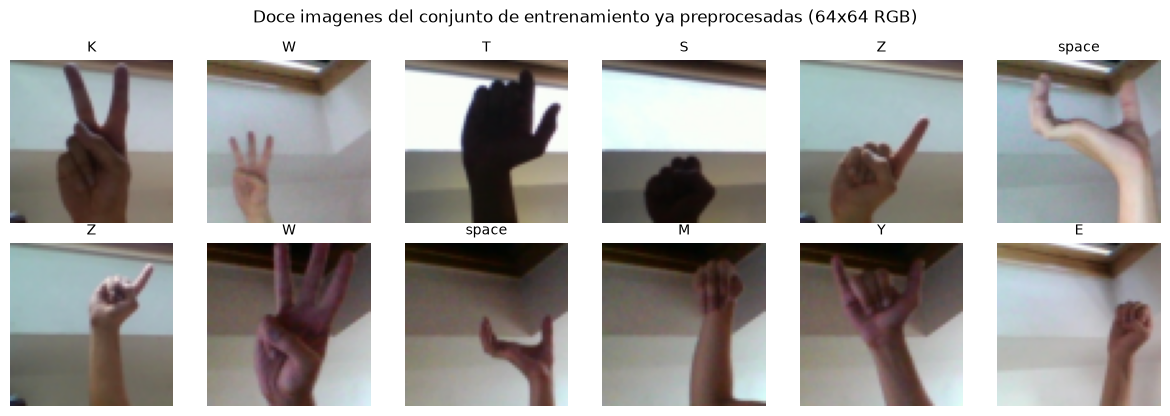

In [13]:
# Como se ven las imagenes que consumira el modelo
X_train, y_train = datos["train"]
idx = rng.choice(len(X_train), 12, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(12, 4.2))
for ax, i in zip(axes.flat, idx):
    ax.imshow(X_train[i])
    ax.set_title(clases[y_train[i]], fontsize=10)
    ax.axis("off")
fig.suptitle("Doce imagenes del conjunto de entrenamiento ya preprocesadas (64x64 RGB)")
plt.tight_layout()
plt.show()

## 9. Resumen del preprocesamiento

### Lo que se le hizo a las imágenes

| # | Paso | Herramienta | Parámetro | Motivo |
|---|---|---|---|---|
| 1 | Submuestreo | `random.Random(42).sample` | 500 imágenes por clase (14,500 en total) | El dataset completo pesaría 10,440 MB en `uint8`, más del triple de la RAM total de la máquina. 500 por clase conserva el balance perfecto y deja el margen de memoria más amplio |
| 2 | Selección aleatoria dentro de cada clase | semilla 42 | — | Las fotos vienen de secuencias de video: tomar las primeras 500 daría fotogramas casi idénticos |
| 3 | Conversión a RGB | `PIL.Image.convert("RGB")` | 3 canales | Garantiza un número uniforme de canales |
| 4 | **Recorte del borde** | `PIL.Image.crop` | **3 px de cada lado** (200×200 → 194×194) | Las fotos traen un marco azul grabado en el margen; no aporta información, se convierte en bandas al aplicar aumento y no existirá en las fotos del ejercicio 8 |
| 5 | Cambio de resolución | `PIL.Image.resize`, bilineal | 194×194 → **64×64** | Diez veces menos píxeles, y la estructura de los dedos todavía es legible (a 32×32 ya no) |
| 6 | Almacenamiento | `numpy.save` | `uint8` | 178 MB en lugar de 713 MB que ocuparía en `float32` |
| 7 | Normalización | `keras.layers.Rescaling(1/255)` | rango [0, 1] | Las redes son sensibles a la escala. Se aplica **por lote dentro del modelo** para no cuadruplicar la memoria |
| 8 | Filtros | ninguno en la entrada base | — | Se evaluaron grises, CLAHE, desenfoque y Canny; ninguno se aplica a las redes, que aprenden sus propios filtros |
| 9 | Partición | `train_test_split` × 2, `stratify=y` | 70 / 15 / 15, semilla 42 | El conjunto de prueba oficial de Kaggle solo trae 28 imágenes |

### Resultado

`data/processed/` contiene los arreglos listos para entrenar:

| Archivo | Forma | Tipo | Tamaño |
|---|---|---|---|
| `X_train.npy` / `y_train.npy` | (10150, 64, 64, 3) | `uint8` | 125 MB |
| `X_val.npy` / `y_val.npy` | (2175, 64, 64, 3) | `uint8` | 27 MB |
| `X_test.npy` / `y_test.npy` | (2175, 64, 64, 3) | `uint8` | 27 MB |

Más `clases.json` con el mapeo de índice a letra y `metadata.json` con todos los parámetros usados, de modo que el proceso completo se puede reproducir con `python src/preprocess.py --per-class 500 --size 64`.